# Artificial Neural Networks with Keras — Pima Indians Diabetes Dataset

**Task**

Build and compare three ANN architectures using `tensorflow.keras` on the Pima Indians Diabetes dataset:

| Model | Hidden layers |
|---|---|
| Shallow | 1 hidden layer |
| Deeper | 2 hidden layers (12, 8 nodes) |
| More deep | 3 hidden layers (32, 16, 8 nodes) |

**Settings (fixed for all models):**
- Hidden layers activation: `ReLU`
- Output layer activation: `sigmoid`
- Loss: `binary_crossentropy`
- Optimizer: `adam`
- Metrics: `accuracy`
- Epochs: `150`

The models are trained on a train split and evaluated on a held-out test split, so the comparison reflects generalization performance rather than training-set memorization.

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import plot_model

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

EPOCHS = 150
BATCH_SIZE = 10  # Keras default is 32; 10 is a common choice for this small dataset

## 2. Load the Dataset

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome",
]

df = pd.read_csv(url, header=None, names=columns)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()
print("\nClass balance (Outcome):")
print(df["Outcome"].value_counts(normalize=True).round(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Class balance (Outcome):
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


## 3. Prepare the Data

- Split features (`X`) and target (`y`)
- Split into train/test sets (80/20, stratified so both sets keep the same class balance)
- Standardize the features (zero mean, unit variance) — this speeds up and stabilizes training for neural networks

In [4]:
X = df.drop(columns=["Outcome"]).values
y = df["Outcome"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # fit only on train to avoid data leakage

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (614, 8), X_test: (154, 8)


## 4. Helper Function

A single function builds, compiles, trains and evaluates a model given a list of hidden-layer sizes, so the three architectures share identical, bug-free logic instead of three copy-pasted blocks.

In [5]:
def build_and_train_model(hidden_layers, name):
    """Build, compile, train and evaluate a Sequential ANN.

    Parameters
    ----------
    hidden_layers : list[int]
        Number of nodes in each hidden layer, e.g. [12, 8].
    name : str
        Label used for printing and plot legends.
    """
    model = Sequential(name=name.replace(" ", "_"))
    model.add(Input(shape=(X_train.shape[1],)))
    for units in hidden_layers:
        model.add(Dense(units, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

    print(f"--- {name} Model ({len(hidden_layers)} hidden layer(s): {hidden_layers}) ---")
    model.summary()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n{name} Model -> Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}\n")

    return model, history, test_loss, test_acc

## 5. Train the Three Architectures

In [6]:
model_shallow, history_shallow, loss_shallow, acc_shallow = build_and_train_model(
    hidden_layers=[12], name="Shallow"
)

--- Shallow Model (1 hidden layer(s): [12]) ---


Model: "Shallow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)


Shallow Model -> Test Loss: 0.5185, Test Accuracy: 0.7338



In [7]:
model_deeper, history_deeper, loss_deeper, acc_deeper = build_and_train_model(
    hidden_layers=[12, 8], name="Deeper"
)

--- Deeper Model (2 hidden layer(s): [12, 8]) ---


Model: "Deeper"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)


Deeper Model -> Test Loss: 0.5560, Test Accuracy: 0.7403



In [8]:
model_more_deep, history_more_deep, loss_more_deep, acc_more_deep = build_and_train_model(
    hidden_layers=[32, 16, 8], name="More_Deep"
)

--- More_Deep Model (3 hidden layer(s): [32, 16, 8]) ---


Model: "More_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)


More_Deep Model -> Test Loss: 1.9230, Test Accuracy: 0.6883



## 6. Visualize the Architecture of Each Network

`plot_model` draws the layer graph of each model (layer types, shapes, and connections), which is a clearer way to see the difference between the shallow/deeper/more-deep networks than the text summary alone.

Shallow Model Architecture:


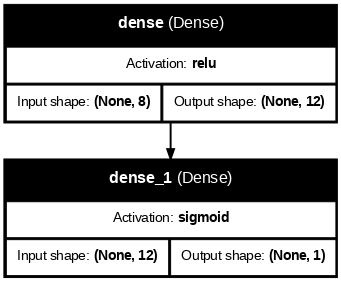

Deeper Model Architecture:


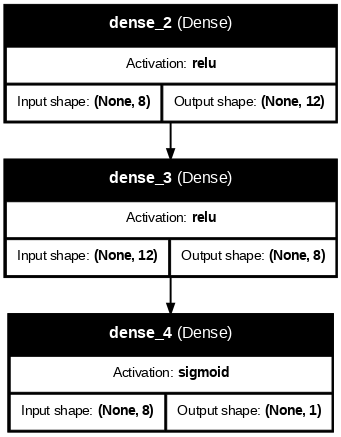

More Deep Model Architecture:


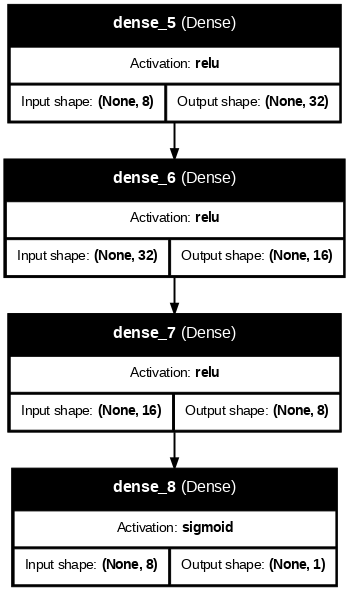

In [9]:
models = {
    "Shallow": model_shallow,
    "Deeper": model_deeper,
    "More Deep": model_more_deep,
}

for name, model in models.items():
    print(f"{name} Model Architecture:")
    display(plot_model(
        model,
        show_shapes=True,
        show_layer_names=True,
        show_layer_activations=True,
        rankdir="TB",
        dpi=70,
    ))

## 7. Compare Training Curves

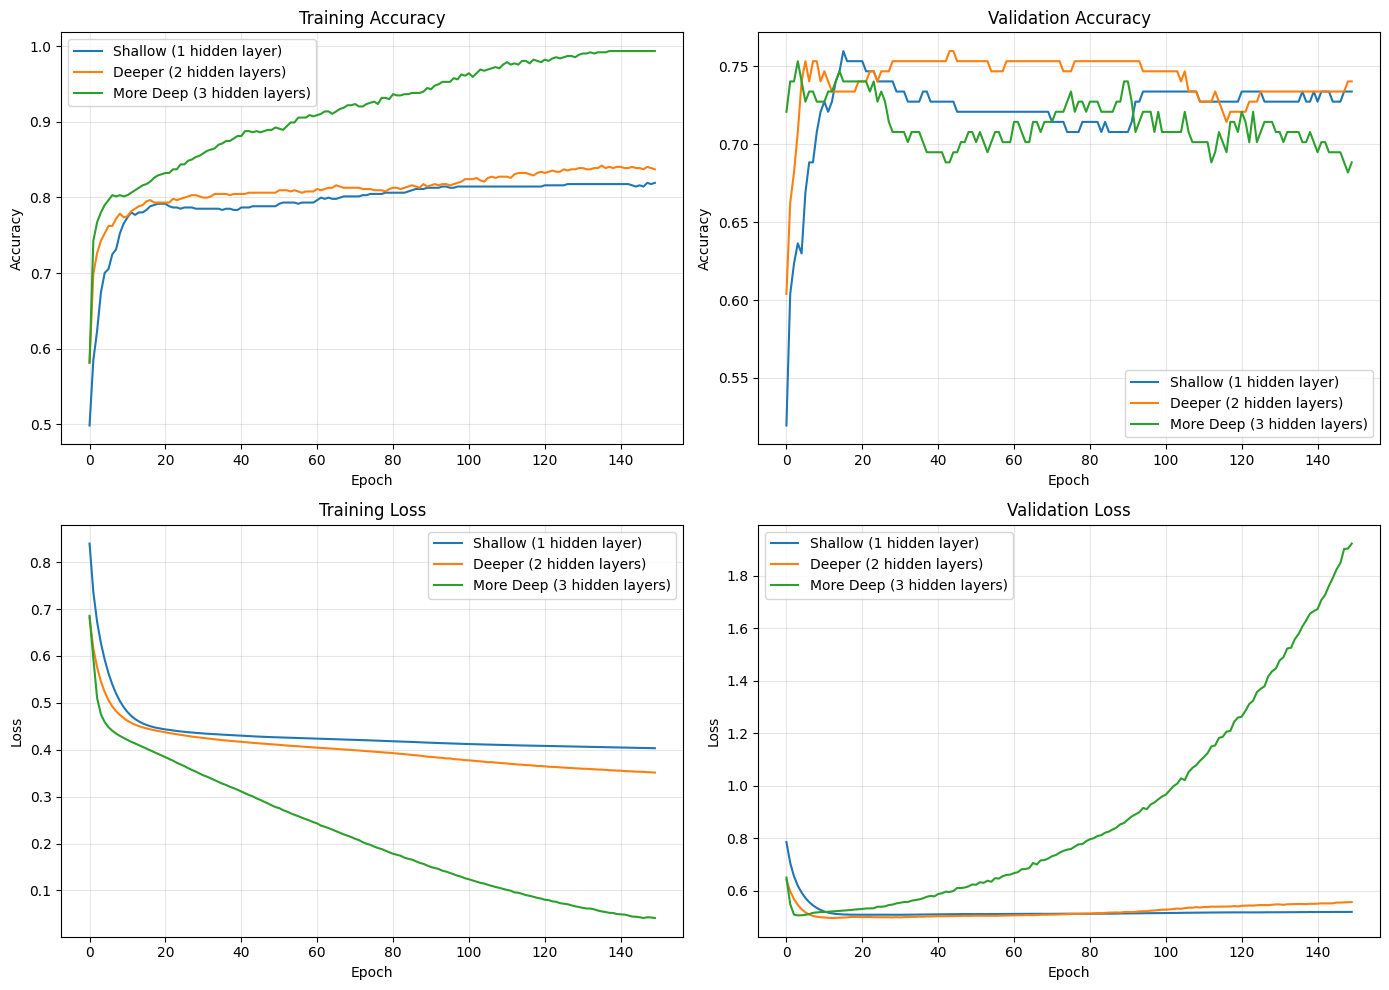

In [10]:
histories = {
    "Shallow (1 hidden layer)": history_shallow,
    "Deeper (2 hidden layers)": history_deeper,
    "More Deep (3 hidden layers)": history_more_deep,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for label, h in histories.items():
    axes[0, 0].plot(h.history["accuracy"], label=label)
    axes[0, 1].plot(h.history["val_accuracy"], label=label)
    axes[1, 0].plot(h.history["loss"], label=label)
    axes[1, 1].plot(h.history["val_loss"], label=label)

titles = ["Training Accuracy", "Validation Accuracy", "Training Loss", "Validation Loss"]
ylabels = ["Accuracy", "Accuracy", "Loss", "Loss"]

for ax, title, ylabel in zip(axes.flat, titles, ylabels):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Summary Table

In [11]:
summary = pd.DataFrame({
    "Model": ["Shallow", "Deeper", "More Deep"],
    "Hidden Layers": ["[12]", "[12, 8]", "[32, 16, 8]"],
    "Trainable Params": [
        model_shallow.count_params(),
        model_deeper.count_params(),
        model_more_deep.count_params(),
    ],
    "Test Loss": [loss_shallow, loss_deeper, loss_more_deep],
    "Test Accuracy": [acc_shallow, acc_deeper, acc_more_deep],
})

summary = summary.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
summary

,Model,Hidden Layers,Trainable Params,Test Loss,Test Accuracy
0,Deeper,"[12, 8]",221,0.555971,0.740260
1,Shallow,[12],121,0.518473,0.733766
2,More Deep,"[32, 16, 8]",961,1.922975,0.688312


## 9. Conclusion

- All three models use `ReLU` hidden activations, a `sigmoid` output, `binary_crossentropy` loss, the `adam` optimizer, and train for 150 epochs, as required.
- Performance is measured on a held-out **test set** (not the training data), so the comparison reflects how well each architecture generalizes rather than how well it memorizes.
- The summary table above ranks the three architectures by test accuracy — re-run the notebook to see which depth works best for this dataset and random seed. On a small dataset like this (~768 rows), deeper networks don't always outperform shallower ones, since they have more parameters to overfit with relative to the amount of data available.